<h1>Importing needed frameworks</h1>

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


<h1>Loading datasets</h1>

In [245]:
obesity_adults = pd.read_csv('data/obesity_adults.csv')
obesity_kids = pd.read_csv('data/obesity_kids.csv')
gdp = pd.read_csv('data/gdp.csv')
education = pd.read_csv('data/education.csv')
food = pd.read_csv('data/food.csv')

<h1>Utils</h1>

In [246]:
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"
eu_country_codes = {
    'Austria': 'AUT',
    'Belgium': 'BEL',
    'Bulgaria': 'BGR',
    'Croatia': 'HRV',
    'Cyprus': 'CYP',
    'Czechia': 'CZE',
    'Denmark': 'DNK',
    'Estonia': 'EST',
    'Finland': 'FIN',
    'France': 'FRA',
    'Germany': 'DEU',
    'Greece': 'GRC',
    'Hungary': 'HUN',
    'Ireland': 'IRL',
    'Italy': 'ITA',
    'Latvia': 'LVA',
    'Lithuania': 'LTU',
    'Luxembourg': 'LUX',
    'Malta': 'MLT',
    'Netherlands (Kingdom of the)': 'NLD',
    'Poland': 'POL',
    'Portugal': 'PRT',
    'Romania': 'ROU',
    'Slovakia': 'SVK',
    'Slovenia': 'SVN',
    'Spain': 'ESP',
    'Sweden': 'SWE'
}
iso3_to_iso2 = {
    'AUT': 'AT',
    'BEL': 'BE',
    'BGR': 'BG',
    'HRV': 'HR',
    'CYP': 'CY',
    'CZE': 'CZ',
    'DNK': 'DK',
    'EST': 'EE',
    'FIN': 'FI',
    'FRA': 'FR',
    'DEU': 'DE',
    'GRC': 'GR',
    'HUN': 'HU',
    'IRL': 'IE',
    'ITA': 'IT',
    'LVA': 'LV',
    'LTU': 'LT',
    'LUX': 'LU',
    'MLT': 'MT',
    'NLD': 'NL',
    'POL': 'PL',
    'PRT': 'PT',
    'ROU': 'RO',
    'SVK': 'SK',
    'SVN': 'SI',
    'ESP': 'ES',
    'SWE': 'SE'
}
education_mapping = {
    "ED0-2": "Elementary/Middle",
    "ED3-4": "High school",
    "ED3_4": "High school",
    "ED34_44": "High school",
    "ED35_45": "High school",
    "ED5-8": "College",
}

<h1>Preprocessing and Cleaning Data</h1>

In [247]:

#Cleaning obesity for adults dataset
obesity = pd.concat([obesity_kids,obesity_adults])
obesity = obesity[['GEO_NAME_SHORT','DIM_TIME','DIM_SEX','DIM_AGE','RATE_PER_100_N']].copy()
obesity.columns = ['country','year','sex','age','obesity_rate']
obesity['country'] = obesity['country'].map(eu_country_codes)
obesity = obesity[obesity['country'].notna()]


<h1>Obesity Map<h1>

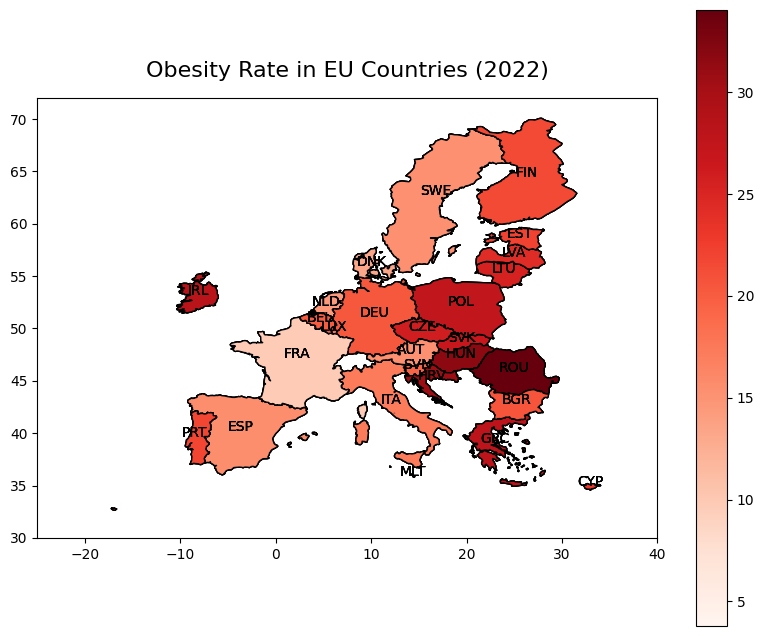

In [248]:

#Preparing the used data and map
data = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022)]
world = gpd.read_file(url)
world.loc[(world['SOV_A3'] == 'FR1') & (world['NAME'] == 'France'),'SOV_A3'] = 'FRA'
world.loc[(world['SOV_A3'] == 'FI1') & (world['NAME'] == 'Finland'),'SOV_A3'] = 'FIN'
world.loc[(world['SOV_A3'] == 'NL1') & (world['NAME'] == 'Netherlands'),'SOV_A3'] = 'NLD'
world.loc[(world['SOV_A3'] == 'DN1') & (world['NAME'] == 'Denmark'),'SOV_A3'] = 'DNK'
eu_map = world[world['SOV_A3'].isin(data['country'])]
#Filtering non-EU countries out

merged = eu_map.merge(data,left_on='SOV_A3',right_on='country',how='left')
figure, axis = plt.subplots(figsize=(10, 8))
merged.plot(column='obesity_rate',cmap='Reds',legend=True,edgecolor='black',linewidth=1,ax=axis)

axis.set_xlim(-25, 40)
axis.set_ylim(30, 72)

# Labels
axis.set_title('Obesity Rate in EU Countries (2022)', fontsize=16, pad=15)
for idx, row in merged.iterrows():
    axis.text(
        row.geometry.centroid.x + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.x,
        row.geometry.centroid.y + 5 if row['SOV_A3'] == 'FRA' else row.geometry.centroid.y,
        row['SOV_A3'],fontsize=10,ha='center'
    )

<h1>Analysis Obesity and sex accross EU countries</h1>

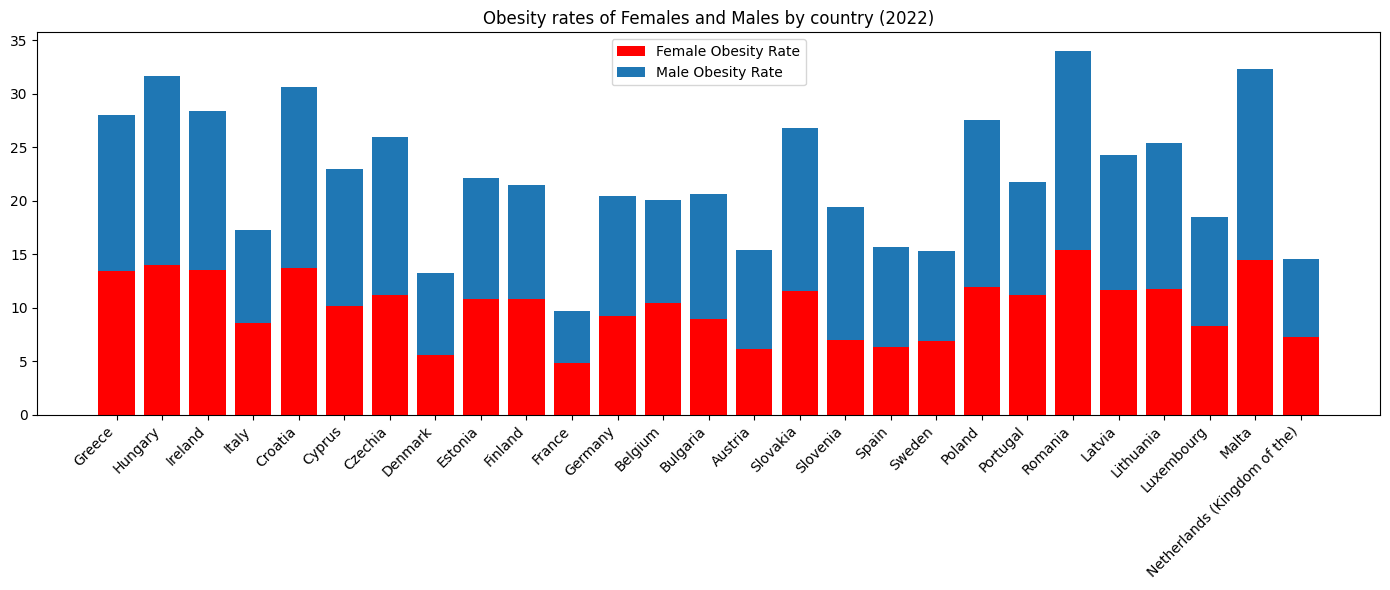

In [249]:
female_obesity = obesity[(obesity['sex'] == 'FEMALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
male_obesity = obesity[(obesity['sex'] == 'MALE') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]
total = obesity[(obesity['sex'] == 'TOTAL') & (obesity['year'] == 2022) & (obesity['age'] == 'Y_GE18')]

df = pd.merge(female_obesity[['country','obesity_rate']],male_obesity[['country','obesity_rate']],on='country',suffixes=('_females','_males'))
df = df.merge(total[['country','obesity_rate']],on='country')
df = df.rename(columns={'obesity_rate':'obesity_rate_total'})
scaler = df['obesity_rate_total'] / (df['obesity_rate_females'] + df['obesity_rate_males'])
df['obesity_female_scaled'] = df['obesity_rate_females'] * scaler
df['obesity_male_scaled'] = df['obesity_rate_males'] * scaler
df['country'] = df['country'].map({v:k for k,v in eu_country_codes.items()})

plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_female_scaled'],label='Female Obesity Rate',color='red')
plt.bar(df['country'],df['obesity_male_scaled'],bottom=df['obesity_female_scaled'],label='Male Obesity Rate')
plt.title('Obesity rates of Females and Males by country (2022)')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.legend()
plt.show()


/var/folders/z1/mjj4kbr57kv_239s2x1tn8hc0000gn/T/ipykernel_25855/3576802517.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


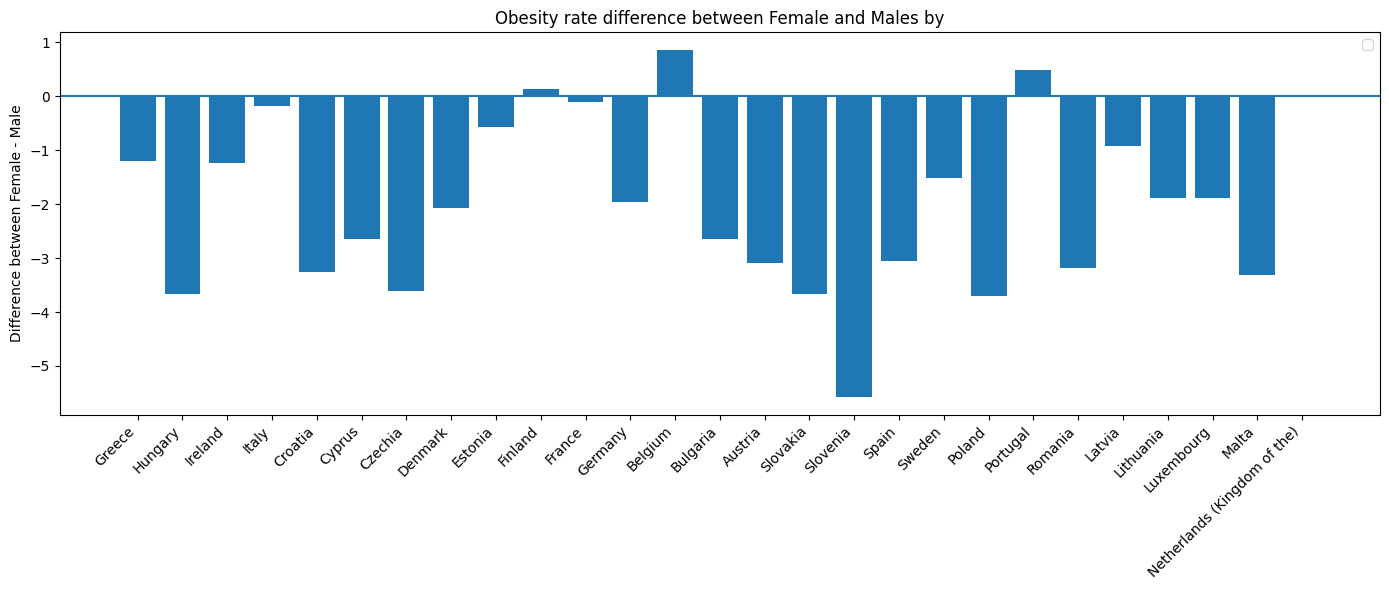

In [250]:
df['obesity_diff'] = df['obesity_female_scaled'] - df['obesity_male_scaled']
df
plt.figure(figsize=(14,6))
plt.bar(df['country'],df['obesity_diff'])
plt.axhline(0)
plt.xticks(rotation=45,ha='right')
plt.ylabel('Difference between Female - Male')
plt.title('Obesity rate difference between Female and Males by')
plt.tight_layout()
plt.legend()
plt.show()

<h1>Obesity and GPD Analysis</h1>

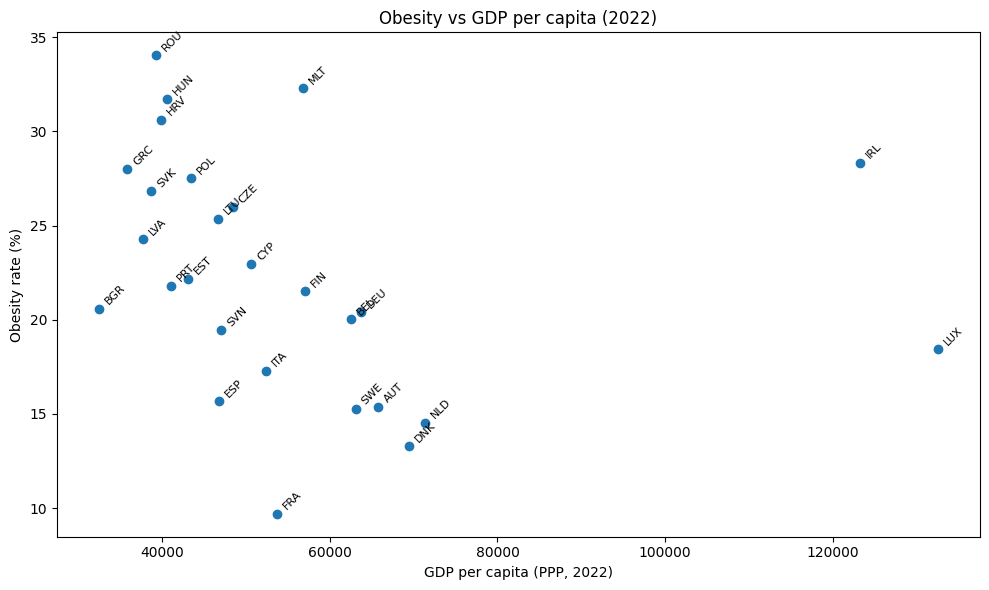

In [251]:
df = pd.merge(obesity,gdp[gdp['Country Code'].isin(eu_country_codes.values())][['Country Code','2022']],left_on='country',right_on='Country Code')
df = df[(df['year'] == 2022) & (df['sex'] == 'TOTAL') & (df['age'] == 'Y_GE18')]

plt.figure(figsize=(10,6))
plt.scatter(df['2022'], df['obesity_rate'])
plt.xlabel("GDP per capita (PPP, 2022)")
plt.ylabel("Obesity rate (%)")
plt.title("Obesity vs GDP per capita (2022)")

# Labels
for i, text in enumerate(df["Country Code"]):
    plt.annotate(
        text,(df["2022"].iloc[i], df["obesity_rate"].iloc[i]),textcoords="offset points",
        xytext=(3,3),rotation=45,fontsize=8
    )
    
plt.tight_layout()
plt.show()

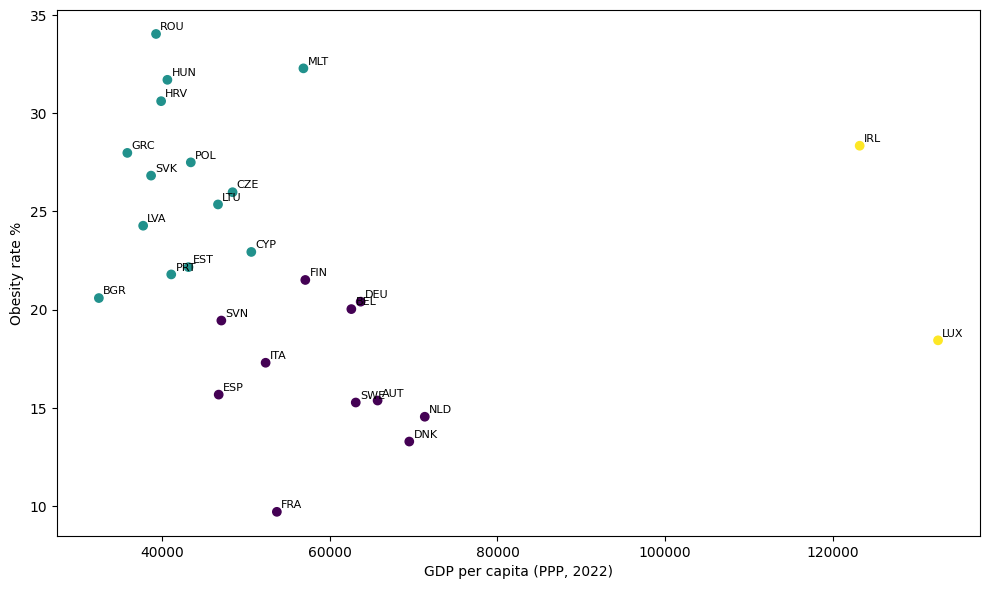

In [252]:
X = df[["2022", "obesity_rate"]].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
best_score = -np.inf
best_k = None
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
y_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(df["2022"],df["obesity_rate"],c=y_labels)

for i, txt in enumerate(df["Country Code"]):
    plt.annotate(txt,(df["2022"].iloc[i], df["obesity_rate"].iloc[i]),textcoords="offset points",xytext=(3,3),fontsize=8)

plt.xlabel("GDP per capita (PPP, 2022)")
plt.ylabel("Obesity rate %")

plt.tight_layout()
plt.show()

<h1>Analysis of education and obesity</h1>

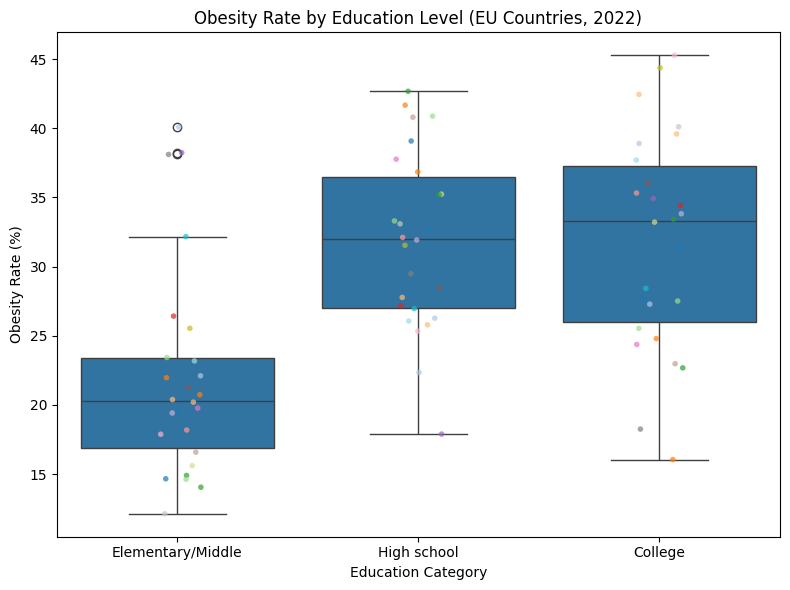

In [253]:


df_2022 = education[education["TIME_PERIOD"] == 2022].copy()
df_2022["isced11"].unique()
df_2022["OBS_VALUE"] = pd.to_numeric(df_2022["OBS_VALUE"], errors="coerce")
df_2022 = df_2022.dropna(subset=["OBS_VALUE"])
df_2022 = df_2022[df_2022["geo"].isin(iso3_to_iso2.values())]
df_2022["education_group"] = df_2022["isced11"].map(education_mapping)
df_2022 = df_2022.dropna(subset=["education_group"])
df_2022 = df_2022.groupby(["geo", "education_group"])["OBS_VALUE"].mean().reset_index()
order = ["Elementary/Middle", "High school", "College"]
plt.figure(figsize=(8, 6))

sns.boxplot(data=df_2022,x="education_group",y="OBS_VALUE",order=order)
sns.stripplot(data=df_2022,x="education_group",y="OBS_VALUE",order=order,hue="geo",palette="tab20",jitter=True,size=4,alpha=0.7,legend=False)

plt.title("Obesity Rate by Education Level (EU Countries, 2022)")
plt.xlabel("Education Category")
plt.ylabel("Obesity Rate (%)")

plt.tight_layout()
plt.show()

<h1>Analysis of obesity and food</h1>

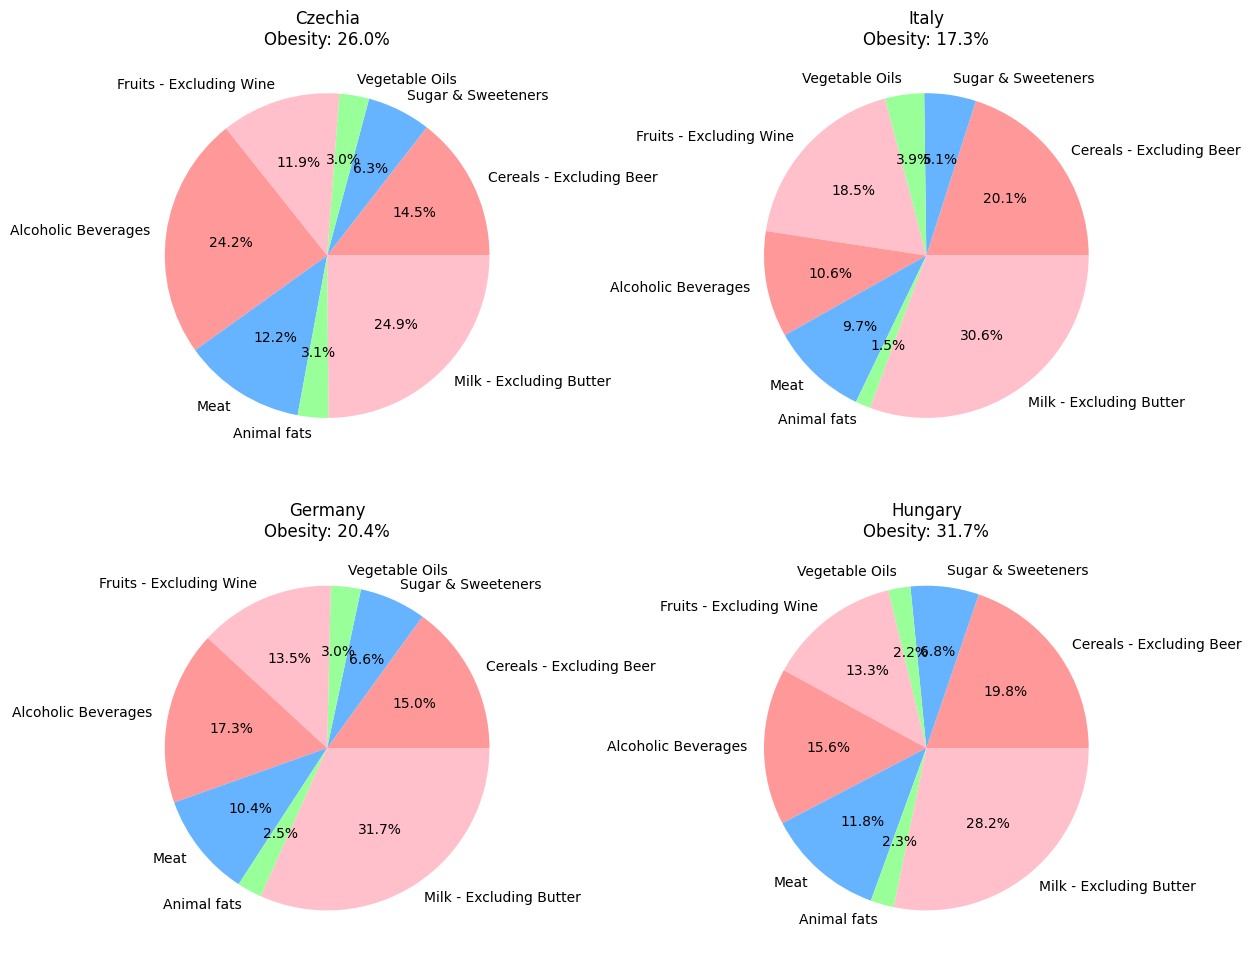

In [254]:
import pandas as pd
import matplotlib.pyplot as plt

df = food[food['Area'].isin(eu_country_codes.keys())]
df = df.rename(columns={'Area': 'country'})
food_items = ['Cereals - Excluding Beer',       'Sugar & Sweeteners',
           'Vegetable Oils',  'Fruits - Excluding Wine',
      'Alcoholic Beverages',                     'Meat',
              'Animal fats',  'Milk - Excluding Butter']
df = df[df['Item'].isin(food_items)]
table = df.pivot_table(index='country',columns='Item',values='Value').reset_index()
temp_obesity = obesity.copy()
temp_obesity['country'] = temp_obesity['country'].map({v: k for k, v in eu_country_codes.items()})
temp_obesity = temp_obesity[(temp_obesity['year'] == 2022) &(temp_obesity['age'] == 'Y_GE18') &(temp_obesity['sex'] == 'TOTAL')]
df = table.merge(temp_obesity[['country', 'obesity_rate']],on='country',how='inner')
countries = ['Czechia', 'Italy', 'Germany', 'Hungary']
colors = ['#ff9999', '#66b3ff', '#99ff99', 'pink']
explode = (0.05, 0.05, 0.05, 0.05)

#plotting
plt.figure(figsize=(12,10))
for i, country in enumerate(countries):
    data = df[df['country'] == country]
    values = data[food_items].values.flatten()
    obesity_val = data['obesity_rate'].values[0]
    
    plt.subplot(2, 2, i+1)
    plt.pie(values,labels=food_items,autopct='%1.1f%%',colors=colors,)
    plt.title(f"{country}\nObesity: {obesity_val:.1f}%")

plt.tight_layout()
plt.show()